## Model Training

The cleaned dataset is split into training and testing sets using stratified sampling to preserve the spam-ham class distribution while shuffling the data to reduce ordering bias. A Multinomial Naive Bayes classifier is used, as it is well suited to TF-IDF text features. Model hyperparameters, including the smoothing parameter (`alpha`) and TF-IDF settings, are tuned using a grid search, with the best configuration selected based on F1 score. The final trained model is then saved for evaluation and deployment.


In [ ]:
# Mounting Google Drive to access the dataset. Alternatively, you may upload the dataset directly from your local storage.

from google.colab import drive
drive.mount('/content/drive')

# Change this according to where your dataset is stored.
dataset_path ="/content/drive/MyDrive/Spam-Ham Dataset/cleaned.csv"

Mounted at /content/drive


In [ ]:
!nvidia-smi

Sat Jun 13 20:15:06 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
# Import all required packages for the preprocessing.

import pandas as pd
import numpy as np
import joblib
import os
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import (classification_report, f1_score,
                             accuracy_score, roc_auc_score)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Create models folder inside Colab
MODEL_DIR = "/content/models"
os.makedirs(MODEL_DIR, exist_ok=True)

print("Models folder created at:", MODEL_DIR)

Models folder created at: /content/models


In [ ]:
# Load the dataset and perform basic inspection

df = pd.read_csv(dataset_path)

print("Dataset loaded successfully.")
print("Shape of dataset:", df.shape)
print("First few rows of dataset:")
print(df.head())

Dataset loaded successfully.
Shape of dataset: (191594, 3)
First few rows of dataset:
                                                text label  label_enc
0  viagra only one want make her scream prodigy s...  Spam          1
1  thought look original message operation mailto...   Ham          0
2  escapenumber here not ific here escapelong int...  Spam          1
3  start increasing your odds success live sexual...  Spam          1
4  author date escapenumber escapenumber escapenu...   Ham          0


In [ ]:
# Train/Test split

X = df["text"]
y = df["label_enc"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    shuffle=True,
    stratify=y
)

print(f"Train size : {len(X_train)}")
print(f"Test size  : {len(X_test)}")
print(f"\nTrain class distribution:\n{y_train.value_counts()}")
print(f"\nTest class distribution:\n{y_test.value_counts()}")

Train size : 153275
Test size  : 38319

Train class distribution:
label_enc
0    80489
1    72786
Name: count, dtype: int64

Test class distribution:
label_enc
0    20122
1    18197
Name: count, dtype: int64


In [ ]:
# Perform a grid search over TF-IDF and MultinomialNB parameters,
# including vocabulary size, n-gram range, and alpha smoothing.
# The best model is selected based on F1 score.

param_grid = [
    {"max_features": 30000, "ngram_range": (1, 1), "alpha": 0.1},
    {"max_features": 30000, "ngram_range": (1, 2), "alpha": 0.1},
    {"max_features": 50000, "ngram_range": (1, 1), "alpha": 0.5},
    {"max_features": 50000, "ngram_range": (1, 2), "alpha": 0.5},
    {"max_features": 50000, "ngram_range": (1, 1), "alpha": 1.0},
    {"max_features": 50000, "ngram_range": (1, 2), "alpha": 1.0},
]

results = []

for params in param_grid:
    pipeline = Pipeline([
        ("tfidf", TfidfVectorizer(
            max_features=params["max_features"],
            ngram_range=params["ngram_range"],
            sublinear_tf=True          # dampens extreme word frequencies
        )),
        ("nb", MultinomialNB(alpha=params["alpha"]))
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    f1  = f1_score(y_test, y_pred)
    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    results.append({**params, "f1": round(f1, 4),
                    "accuracy": round(acc, 4), "auc": round(auc, 4),
                    "model": pipeline})

    print(f"max_features={params['max_features']} | "
          f"ngram={params['ngram_range']} | "
          f"alpha={params['alpha']} | "
          f"F1={f1:.4f} | AUC={auc:.4f}")

max_features=30000 | ngram=(1, 1) | alpha=0.1 | F1=0.9466 | AUC=0.9929
max_features=30000 | ngram=(1, 2) | alpha=0.1 | F1=0.9430 | AUC=0.9938
max_features=50000 | ngram=(1, 1) | alpha=0.5 | F1=0.9486 | AUC=0.9935
max_features=50000 | ngram=(1, 2) | alpha=0.5 | F1=0.9459 | AUC=0.9945
max_features=50000 | ngram=(1, 1) | alpha=1.0 | F1=0.9475 | AUC=0.9931
max_features=50000 | ngram=(1, 2) | alpha=1.0 | F1=0.9454 | AUC=0.9943


In [ ]:
# Pick the best model

results_df = pd.DataFrame(results).drop(columns="model")
print(results_df.sort_values("f1", ascending=False).to_string(index=False))

 max_features ngram_range  alpha     f1  accuracy    auc
        50000      (1, 1)    0.5 0.9486    0.9523 0.9935
        50000      (1, 1)    1.0 0.9475    0.9513 0.9931
        30000      (1, 1)    0.1 0.9466    0.9504 0.9929
        50000      (1, 2)    0.5 0.9459    0.9503 0.9945
        50000      (1, 2)    1.0 0.9454    0.9498 0.9943
        30000      (1, 2)    0.1 0.9430    0.9476 0.9938


In [ ]:
best = max(results, key=lambda x: x["f1"])
best_model = best["model"]

print("Best combination:")
print(f"  max_features : {best['max_features']}")
print(f"  ngram_range  : {best['ngram_range']}")
print(f"  alpha        : {best['alpha']}")
print(f"  F1 Score     : {best['f1']}")
print(f"  Accuracy     : {best['accuracy']}")
print(f"  AUC          : {best['auc']}")

Best combination:
  max_features : 50000
  ngram_range  : (1, 1)
  alpha        : 0.5
  F1 Score     : 0.9486
  Accuracy     : 0.9523
  AUC          : 0.9935


In [ ]:
# Full classification report

y_pred_best = best_model.predict(X_test)
print(classification_report(y_test, y_pred_best, target_names=["Ham", "Spam"]))

              precision    recall  f1-score   support

         Ham       0.94      0.98      0.96     20122
        Spam       0.97      0.93      0.95     18197

    accuracy                           0.95     38319
   macro avg       0.95      0.95      0.95     38319
weighted avg       0.95      0.95      0.95     38319



In [ ]:
# Save the best model

MODEL_DIR = "/content/models"
os.makedirs(MODEL_DIR, exist_ok=True)

MODEL_PATH = os.path.join(MODEL_DIR, "naive_bayes_model.pkl")

joblib.dump(best_model, MODEL_PATH, compress=3)

print("Model saved to:", MODEL_PATH)

Model saved to: /content/models/naive_bayes_model.pkl


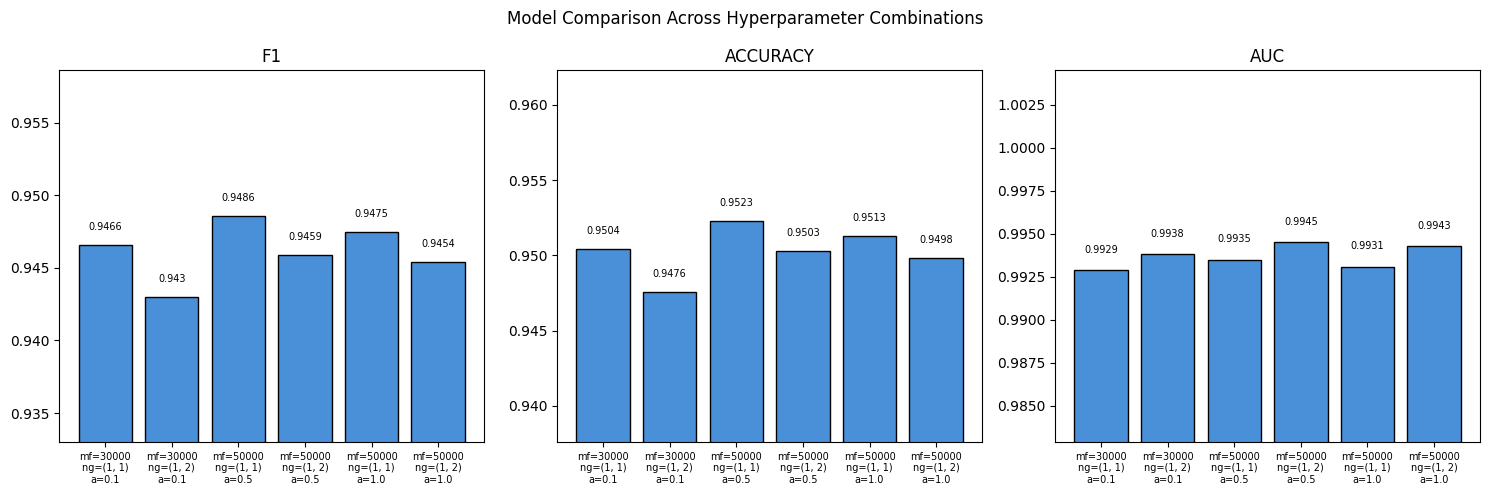

Plot saved to: /content/assets/model_training_plots/model_comparison.png


In [ ]:
# Result comparison plot

# Create assets folder inside Colab
PLOT_DIR = "/content/assets/model_training_plots"
os.makedirs(PLOT_DIR, exist_ok=True)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

labels = [
    f"mf={r['max_features']}\nng={r['ngram_range']}\na={r['alpha']}"
    for r in results
]

for ax, metric in zip(axes, ["f1", "accuracy", "auc"]):
    values = [r[metric] for r in results]

    bars = ax.bar(labels, values, color="#4a90d9", edgecolor="black")
    ax.set_title(metric.upper())
    ax.set_ylim(min(values) - 0.01, max(values) + 0.01)
    ax.tick_params(axis="x", labelsize=7)

    for bar, val in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.001,
            str(val),
            ha="center",
            fontsize=7
        )

plt.suptitle("Model Comparison Across Hyperparameter Combinations", fontsize=12)
plt.tight_layout()

SAVE_PATH = "/content/assets/model_training_plots/model_comparison.png"
plt.savefig(SAVE_PATH, dpi=300, bbox_inches="tight")

plt.show()

print("Plot saved to:", SAVE_PATH)

## Training Summary

The best-performing model used a **TF-IDF vectorizer** with **50,000 features**, **unigrams only (`ngram_range=(1,1)`)**, and a **Multinomial Naive Bayes classifier** with **alpha = 0.5**. This configuration achieved an **accuracy of 95.23%**, an **F1 score of 0.9486**, and a **ROC-AUC score of 0.9935**.

Interestingly, all of the top-performing configurations used unigrams rather than bigrams. While adding bigrams substantially increased the vocabulary size, it did not improve classification performance, suggesting that individual words already provide sufficient information for distinguishing spam from ham emails.

The classification report shows strong performance across both classes. Ham emails achieved particularly high recall, indicating that very few legitimate emails were incorrectly classified as spam. Spam precision was also high, meaning that emails flagged as spam were usually classified correctly. The primary area for improvement is spam recall, where a small proportion of spam emails are still misclassified as ham.

The ROC-AUC score of **0.9935** indicates excellent class separation, demonstrating that the model is highly effective at ranking spam emails above legitimate emails across a range of classification thresholds.

The final trained model has been saved to:

`models/naive_bayes_model.pkl`
